In [1]:
# ============================================================
# MODELO QSAR — BAJA POTENCIA v4 (clustering GMM)
# Umbral: Log10 EC50 > 5.5 nM
#
# Estrategia: 2 sub-modelos por cluster GMM
#   Cluster 0: zona densa  5.5–6.3  (~377 mol)
#   Cluster 1: zona esparsa 6.3–7.8  (~82 mol)
#
# Mismo patrón que funcionó en Media Potencia (R² global=0.86)
# ============================================================

# ── CELDA 1 — Instalación ─────────────────────────────────────
!pip install rdkit --quiet
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 41.2 MB/s eta 0:00:00


In [2]:
# ── CELDA 2 — Imports ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
)
from sklearn.svm import SVR
from sklearn.mixture import GaussianMixture
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib, os

from google.colab import drive

RANDOM_SEED = 42
PALETTE_C   = ["#2196F3", "#FF5722"]        # azul / naranja por cluster
PALETTE_M   = {
    "GradientBoosting": "#4CAF50",
    "RandomForest":     "#2196F3",
    "ExtraTrees":       "#E91E63",
    "SVM":              "#FF9800",
}

In [3]:
# ── CELDA 3 — Cargar y filtrar datos ─────────────────────────
drive.mount('/content/drive')

RUTA_CSV = "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/EC50_molecules_reclassified.csv"

database = pd.read_csv(RUTA_CSV)
database['Log10 Value (nM)'] = pd.to_numeric(database['Log10 Value (nM)'], errors='coerce')

df = database[database['Log10 Value (nM)'] > 5.5].copy()
df = df[['Molecule ChEMBL ID', 'Smiles', 'Log10 Value (nM)']].dropna()
df.columns = ['chembl_id', 'smiles', 'log10_ec50']
df = df.reset_index(drop=True)

print(f"Moléculas Baja Potencia (Log10 > 5.5): {len(df)}")
print(df['log10_ec50'].describe().round(4))

# Eliminar outliers extremos (Q3 + 2.5×IQR)
y_raw = df['log10_ec50'].values
Q1, Q3 = np.percentile(y_raw, 25), np.percentile(y_raw, 75)
upper  = Q3 + 2.5 * (Q3 - Q1)
df     = df[df['log10_ec50'] <= upper].reset_index(drop=True)
print(f"\nTras outliers (límite={upper:.3f}): {len(df)} moléculas")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Moléculas Baja Potencia (Log10 > 5.5): 477
count    477.0000
mean       6.1887
std        0.6478
min        5.5040
25%        5.7850
50%        6.0000
75%        6.3690
max        9.4830
Name: log10_ec50, dtype: float64

Tras outliers (límite=7.829): 459 moléculas



── Identificación de clusters (GMM n=2) ──
  Cluster 0: n= 351  media=5.904  rango=[5.504, 6.322]
  Cluster 1: n= 108  media=6.695  rango=[6.328, 7.818]


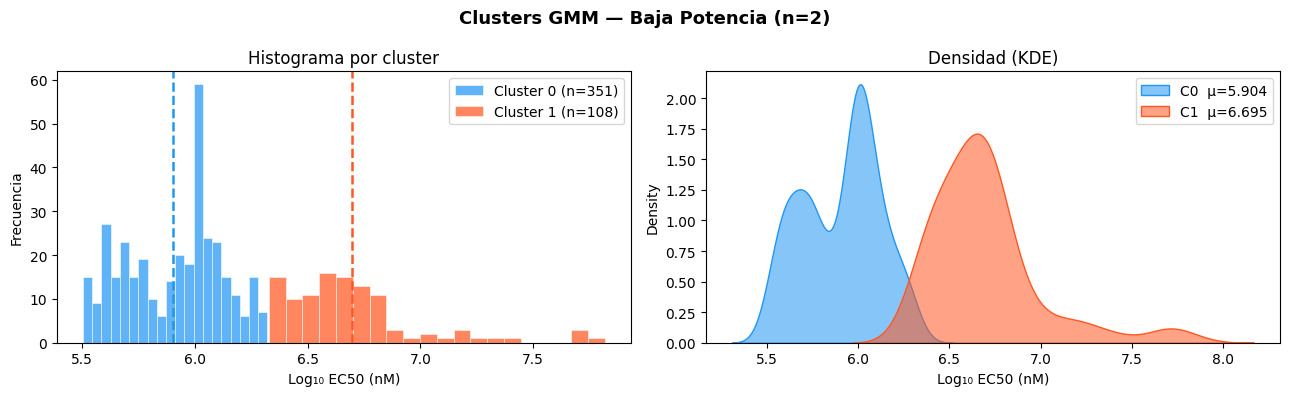

In [4]:
# ── CELDA 4 — Clustering GMM (n=2) ───────────────────────────
print("\n── Identificación de clusters (GMM n=2) ──")

y_vals = df['log10_ec50'].values
gmm    = GaussianMixture(n_components=2, random_state=RANDOM_SEED)
gmm.fit(y_vals.reshape(-1, 1))
raw_labels = gmm.predict(y_vals.reshape(-1, 1))

# Reordenar: Cluster 0 = valores bajos, Cluster 1 = valores altos
order  = np.argsort(gmm.means_.flatten())
remap  = {old: new for new, old in enumerate(order)}
cluster_labels = np.array([remap[l] for l in raw_labels])

for cid in range(2):
    vals = y_vals[cluster_labels == cid]
    print(f"  Cluster {cid}: n={len(vals):4d}  "
          f"media={vals.mean():.3f}  "
          f"rango=[{vals.min():.3f}, {vals.max():.3f}]")

# Visualización clusters
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Clusters GMM — Baja Potencia (n=2)", fontsize=13, fontweight="bold")

for cid in range(2):
    vals = y_vals[cluster_labels == cid]
    axes[0].hist(vals, bins=20, color=PALETTE_C[cid], alpha=0.72,
                 edgecolor="white", linewidth=0.5,
                 label=f"Cluster {cid} (n={len(vals)})")
    axes[0].axvline(vals.mean(), color=PALETTE_C[cid], linestyle="--", linewidth=1.8)
    sns.kdeplot(vals, ax=axes[1], fill=True, color=PALETTE_C[cid],
                alpha=0.55, label=f"C{cid}  μ={vals.mean():.3f}")

axes[0].set_xlabel("Log₁₀ EC50 (nM)"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Histograma por cluster"); axes[0].legend()
axes[1].set_xlabel("Log₁₀ EC50 (nM)"); axes[1].set_title("Densidad (KDE)")
axes[1].legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/baja_v4_clusters.png",
            dpi=150, bbox_inches="tight")
plt.show()


In [5]:
# ── CELDA 5 — Descriptores moleculares ───────────────────────
def get_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    fp4  = np.array([int(bit) for bit in AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024).ToBitString()], dtype=float)
    fp6  = np.array([int(bit) for bit in AllChem.GetMorganFingerprintAsBitVect(mol, 3, 1024).ToBitString()], dtype=float)
    maccs = np.array([int(bit) for bit in rdMolDescriptors.GetMACCSKeysFingerprint(mol).ToBitString()], dtype=float)
    desc = [
        Descriptors.ExactMolWt(mol),       Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),             Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),    Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),        Descriptors.NumAromaticRings(mol),
        Descriptors.FractionCSP3(mol),     Descriptors.NumAliphaticRings(mol),
        Descriptors.NumHeteroatoms(mol),   Descriptors.HeavyAtomCount(mol),
        Descriptors.NumSaturatedRings(mol),
        rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
        rdMolDescriptors.CalcNumSpiroAtoms(mol),
    ]
    return np.concatenate([fp4, fp6, maccs, desc])

print("Calculando descriptores...")
X_list, valid_idx = [], []
for i, smi in enumerate(df['smiles']):
    d = get_descriptors(smi)
    if d is not None:
        X_list.append(d); valid_idx.append(i)

X_full     = np.array(X_list)
y_full     = df['log10_ec50'].iloc[valid_idx].values
cl_all     = cluster_labels[valid_idx]
mask       = np.isfinite(y_full)
X_full, y_full, cl_all = X_full[mask], y_full[mask], cl_all[mask]
print(f"Moléculas: {len(X_full)}  |  Features: {X_full.shape[1]}")

Calculando descriptores...


[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerator
[21:24:24] DEPRECATION WARNING: please use MorganGenerat

Moléculas: 459  |  Features: 2230


In [6]:
# ── CELDA 6 — Limpieza de features ───────────────────────────
vt      = VarianceThreshold(threshold=0.01)
X_vt    = vt.fit_transform(X_full)
corr    = np.corrcoef(X_vt.T)
upper_t = np.triu(np.abs(corr), k=1)
drop    = np.where(np.any(upper_t > 0.95, axis=0))[0]
keep    = np.ones(X_vt.shape[1], dtype=bool); keep[drop] = False
X_clean = X_vt[:, keep]
print(f"Features: {X_full.shape[1]} → {X_vt.shape[1]} (var) → {X_clean.shape[1]} (corr)")

Features: 2230 → 1535 (var) → 1186 (corr)


In [7]:
# ── CELDA 7 — Split global estratificado ─────────────────────
y_bins = pd.qcut(y_full, q=5, labels=False, duplicates='drop')

X_tr_all, X_te_all, y_tr_all, y_te_all, cl_tr, cl_te = train_test_split(
    X_clean, y_full, cl_all,
    test_size=0.20, random_state=RANDOM_SEED, stratify=y_bins
)

print(f"Train: {len(y_tr_all)}  |  Test: {len(y_te_all)}")
for cid in range(2):
    print(f"  Cluster {cid} → train={(cl_tr==cid).sum()}  test={(cl_te==cid).sum()}")

Train: 367  |  Test: 92
  Cluster 0 → train=281  test=70
  Cluster 1 → train=86  test=22


In [8]:
# ── CELDA 8 — Función: mejor modelo por cluster ───────────────
def fit_best_model(X_tr, y_tr, cluster_name):
    n_cv = max(3, min(5, len(y_tr) // 10))
    kf_c = KFold(n_splits=n_cv, shuffle=True, random_state=RANDOM_SEED)

    candidates = {
        "GradientBoosting": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  GradientBoostingRegressor(
                n_estimators=500, learning_rate=0.02, max_depth=4,
                subsample=0.75, min_samples_leaf=3, max_features=0.5,
                random_state=RANDOM_SEED
            ))
        ]),
        "RandomForest": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  RandomForestRegressor(
                n_estimators=500, max_depth=10, max_features=0.3,
                min_samples_leaf=2, random_state=RANDOM_SEED, n_jobs=-1
            ))
        ]),
        "ExtraTrees": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  ExtraTreesRegressor(
                n_estimators=500, max_depth=10, max_features=0.3,
                min_samples_leaf=2, random_state=RANDOM_SEED, n_jobs=-1
            ))
        ]),
        "SVM": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  SVR(kernel="rbf", C=50, epsilon=0.02, gamma="scale"))
        ]),
    }

    best_name, best_score, best_pipe = None, -np.inf, None
    print(f"\n  [{cluster_name}] n={len(y_tr)}  "
          f"rango=[{y_tr.min():.3f}, {y_tr.max():.3f}]  μ={y_tr.mean():.3f}")

    for mname, pipe in candidates.items():
        scores = cross_val_score(pipe, X_tr, y_tr, cv=kf_c,
                                 scoring="r2", n_jobs=-1)
        print(f"    {mname:<20}  CV R² = {scores.mean():.4f} ± {scores.std():.4f}")
        if scores.mean() > best_score:
            best_score, best_name, best_pipe = scores.mean(), mname, pipe

    print(f"  → Mejor: {best_name}  (CV R²={best_score:.4f})")
    best_pipe.fit(X_tr, y_tr)
    return best_pipe, best_name, best_score

In [9]:
# ── CELDA 8 — Función: mejor modelo por cluster ───────────────
def fit_best_model(X_tr, y_tr, cluster_name):
    n_cv = max(3, min(5, len(y_tr) // 10))
    kf_c = KFold(n_splits=n_cv, shuffle=True, random_state=RANDOM_SEED)

    candidates = {
        "GradientBoosting": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  GradientBoostingRegressor(
                n_estimators=500, learning_rate=0.02, max_depth=4,
                subsample=0.75, min_samples_leaf=3, max_features=0.5,
                random_state=RANDOM_SEED
            ))
        ]),
        "RandomForest": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  RandomForestRegressor(
                n_estimators=500, max_depth=10, max_features=0.3,
                min_samples_leaf=2, random_state=RANDOM_SEED, n_jobs=-1
            ))
        ]),
        "ExtraTrees": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  ExtraTreesRegressor(
                n_estimators=500, max_depth=10, max_features=0.3,
                min_samples_leaf=2, random_state=RANDOM_SEED, n_jobs=-1
            ))
        ]),
        "SVM": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  SVR(kernel="rbf", C=50, epsilon=0.02, gamma="scale"))
        ]),
    }

    best_name, best_score, best_pipe = None, -np.inf, None
    print(f"\n  [{cluster_name}] n={len(y_tr)}  "
          f"rango=[{y_tr.min():.3f}, {y_tr.max():.3f}]  μ={y_tr.mean():.3f}")

    for mname, pipe in candidates.items():
        scores = cross_val_score(pipe, X_tr, y_tr, cv=kf_c,
                                 scoring="r2", n_jobs=-1)
        print(f"    {mname:<20}  CV R² = {scores.mean():.4f} ± {scores.std():.4f}")
        if scores.mean() > best_score:
            best_score, best_name, best_pipe = scores.mean(), mname, pipe

    print(f"  → Mejor: {best_name}  (CV R²={best_score:.4f})")
    best_pipe.fit(X_tr, y_tr)
    return best_pipe, best_name, best_score

In [10]:
# ── CELDA 9 — Entrenamiento por cluster ──────────────────────
print("=" * 60)
print("  ENTRENAMIENTO — 2 SUB-MODELOS")
print("=" * 60)

cluster_pipes   = {}
cluster_sels    = {}
cluster_results = {}

for cid in range(2):
    tr_mask = cl_tr == cid
    te_mask = cl_te == cid
    X_tr_c  = X_tr_all[tr_mask]
    y_tr_c  = y_tr_all[tr_mask]
    X_te_c  = X_te_all[te_mask]
    y_te_c  = y_te_all[te_mask]

    # Selección de features por cluster
    rf_sel = RandomForestRegressor(n_estimators=100,
                                   random_state=RANDOM_SEED, n_jobs=-1)
    rf_sel.fit(X_tr_c, y_tr_c)
    sel      = SelectFromModel(rf_sel, threshold="mean", prefit=True)
    X_tr_sel = sel.transform(X_tr_c)
    X_te_sel = sel.transform(X_te_c)
    print(f"\n  Cluster {cid}: features {X_tr_c.shape[1]} → {X_tr_sel.shape[1]}")

    pipe, name, cv_r2 = fit_best_model(X_tr_sel, y_tr_c, f"Cluster {cid}")

    y_pred_tr = pipe.predict(X_tr_sel)
    y_pred_te = pipe.predict(X_te_sel)
    r2_tr  = r2_score(y_tr_c, y_pred_tr)
    r2_te  = r2_score(y_te_c, y_pred_te)
    rmse   = np.sqrt(mean_squared_error(y_te_c, y_pred_te))
    mae    = mean_absolute_error(y_te_c, y_pred_te)

    cluster_pipes[cid]   = pipe
    cluster_sels[cid]    = sel
    cluster_results[cid] = {
        "model_name": name, "cv_r2": cv_r2,
        "r2_train": r2_tr, "r2_test": r2_te,
        "rmse": rmse, "mae": mae, "gap": r2_tr - r2_te,
        "y_tr": y_tr_c, "y_pred_tr": y_pred_tr,
        "y_te": y_te_c, "y_pred_te": y_pred_te,
    }

    print(f"\n  ── Cluster {cid} ({name}) ──")
    print(f"     CV R²    = {cv_r2:.4f}")
    print(f"     Train R² = {r2_tr:.4f}  |  Test R² = {r2_te:.4f}  |  Gap = {r2_tr-r2_te:.4f}")
    print(f"     RMSE = {rmse:.4f}   |  MAE = {mae:.4f}")
    print(f"     {'✅ META R² ≥ 0.70' if r2_te >= 0.70 else f'⚠️  R² = {r2_te:.4f}'}")

  ENTRENAMIENTO — 2 SUB-MODELOS

  Cluster 0: features 1186 → 246

  [Cluster 0] n=281  rango=[5.504, 6.322]  μ=5.903
    GradientBoosting      CV R² = 0.0198 ± 0.1458
    RandomForest          CV R² = 0.1203 ± 0.1097
    ExtraTrees            CV R² = 0.0891 ± 0.1139
    SVM                   CV R² = -0.1070 ± 0.2058
  → Mejor: RandomForest  (CV R²=0.1203)

  ── Cluster 0 (RandomForest) ──
     CV R²    = 0.1203
     Train R² = 0.5416  |  Test R² = 0.1067  |  Gap = 0.4349
     RMSE = 0.1888   |  MAE = 0.1470
     ⚠️  R² = 0.1067

  Cluster 1: features 1186 → 129

  [Cluster 1] n=86  rango=[6.328, 7.818]  μ=6.703
    GradientBoosting      CV R² = 0.3802 ± 0.3000
    RandomForest          CV R² = 0.2926 ± 0.3048
    ExtraTrees            CV R² = 0.3052 ± 0.2658
    SVM                   CV R² = 0.4321 ± 0.2710
  → Mejor: SVM  (CV R²=0.4321)

  ── Cluster 1 (SVM) ──
     CV R²    = 0.4321
     Train R² = 0.9772  |  Test R² = 0.3549  |  Gap = 0.6224
     RMSE = 0.2576   |  MAE = 0.1717
   

In [11]:
# ── CELDA 10 — Resultado global combinado ─────────────────────
y_pred_global    = np.zeros(len(y_te_all))
y_pred_tr_global = np.zeros(len(y_tr_all))

for cid in range(2):
    sel  = cluster_sels[cid]
    pipe = cluster_pipes[cid]
    y_pred_global[cl_te == cid]    = pipe.predict(sel.transform(X_te_all[cl_te == cid]))
    y_pred_tr_global[cl_tr == cid] = pipe.predict(sel.transform(X_tr_all[cl_tr == cid]))

r2_gl_tr  = r2_score(y_tr_all, y_pred_tr_global)
r2_gl_te  = r2_score(y_te_all, y_pred_global)
rmse_gl   = np.sqrt(mean_squared_error(y_te_all, y_pred_global))
mae_gl    = mean_absolute_error(y_te_all, y_pred_global)

print(f"\n{'─'*60}")
print(f"  RESULTADO GLOBAL (dos sub-modelos combinados)")
print(f"{'─'*60}")
print(f"  Train R² = {r2_gl_tr:.4f}")
print(f"  Test  R² = {r2_gl_te:.4f}")
print(f"  RMSE     = {rmse_gl:.4f}  |  MAE = {mae_gl:.4f}")
print(f"  {'✅ META GLOBAL ALCANZADA: R² ≥ 0.70' if r2_gl_te >= 0.70 else f'⚠️  R² global = {r2_gl_te:.4f}'}")

# Comparativa v3 vs v4
print(f"\n  Comparativa:")
print(f"  {'Versión':<30} {'Test R²':>8} {'RMSE':>8}")
print(f"  {'v3 — modelo único (mejor RF)':<30} {'0.4141':>8} {'0.3061':>8}")
print(f"  {'v4 — 2 clusters GMM (global)':<30} {r2_gl_te:>8.4f} {rmse_gl:>8.4f}")



────────────────────────────────────────────────────────────
  RESULTADO GLOBAL (dos sub-modelos combinados)
────────────────────────────────────────────────────────────
  Train R² = 0.9019
  Test  R² = 0.7312
  RMSE     = 0.2074  |  MAE = 0.1529
  ✅ META GLOBAL ALCANZADA: R² ≥ 0.70

  Comparativa:
  Versión                         Test R²     RMSE
  v3 — modelo único (mejor RF)     0.4141   0.3061
  v4 — 2 clusters GMM (global)     0.7312   0.2074


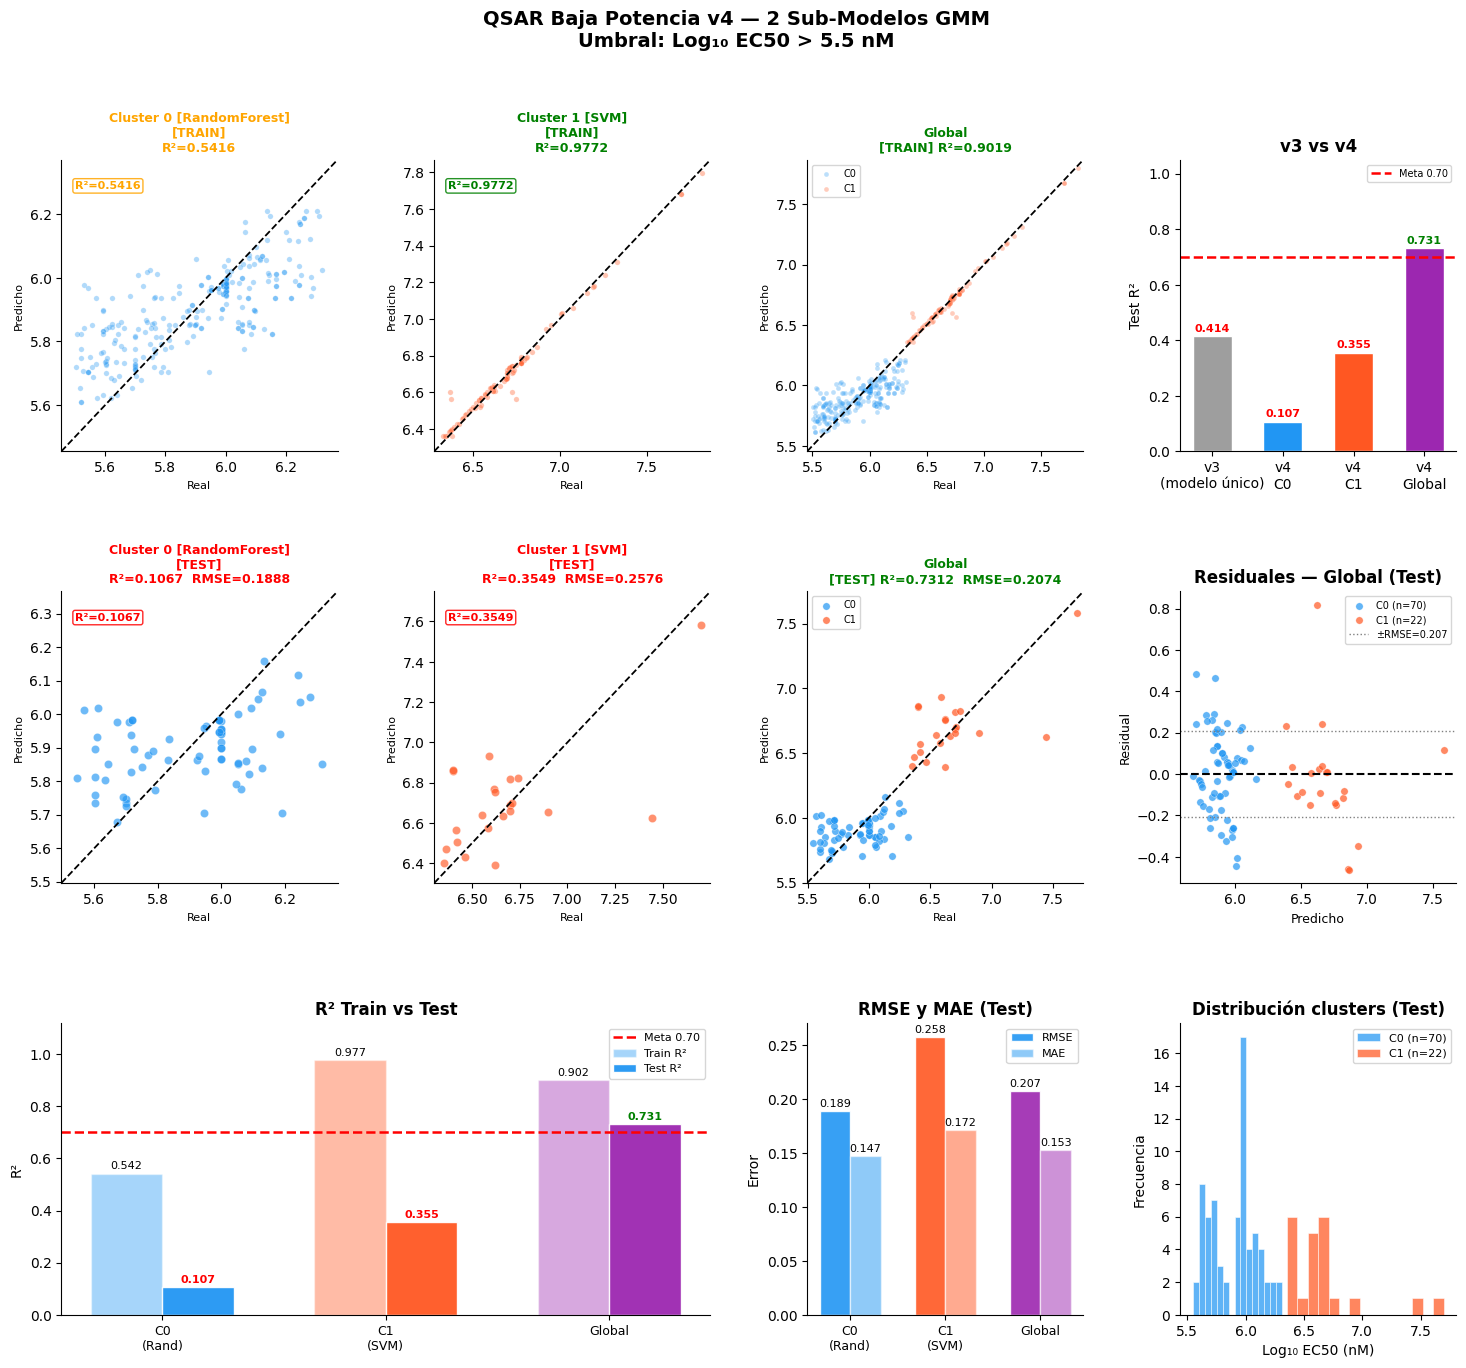

In [12]:
# ── CELDA 11 — Gráfica completa ───────────────────────────────
fig = plt.figure(figsize=(18, 15))
fig.suptitle("QSAR Baja Potencia v4 — 2 Sub-Modelos GMM\nUmbral: Log₁₀ EC50 > 5.5 nM",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.35)

def scatter_ax(ax, yr, yp, color, title, r2, rmse=None, alpha=0.65, s=35):
    ax.scatter(yr, yp, color=color, alpha=alpha,
               edgecolors="white", linewidth=0.3, s=s)
    lo = min(yr.min(), yp.min()) - 0.05
    hi = max(yr.max(), yp.max()) + 0.05
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.3)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Real", fontsize=8); ax.set_ylabel("Predicho", fontsize=8)
    col = "green" if r2 >= 0.70 else ("orange" if r2 >= 0.50 else "red")
    lbl = f"R²={r2:.4f}" + (f"  RMSE={rmse:.4f}" if rmse else "")
    ax.set_title(f"{title}\n{lbl}", fontsize=9, fontweight="bold", color=col)
    ax.text(0.05, 0.90, f"R²={r2:.4f}", transform=ax.transAxes,
            fontsize=8, color=col, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      edgecolor=col, alpha=0.85))
    ax.spines[["top","right"]].set_visible(False)

# Fila 1: TRAIN por cluster + global
for cid in range(2):
    cr = cluster_results[cid]
    scatter_ax(fig.add_subplot(gs[0, cid]),
               cr["y_tr"], cr["y_pred_tr"], PALETTE_C[cid],
               f"Cluster {cid} [{cr['model_name']}]\n[TRAIN]",
               cr["r2_train"], alpha=0.35, s=15)

ax_gtr = fig.add_subplot(gs[0, 2])
for cid in range(2):
    m = cl_tr == cid
    ax_gtr.scatter(y_tr_all[m], y_pred_tr_global[m],
                   color=PALETTE_C[cid], alpha=0.3, s=12,
                   edgecolors="white", linewidth=0.2, label=f"C{cid}")
lo = min(y_tr_all.min(), y_pred_tr_global.min()) - 0.05
hi = max(y_tr_all.max(), y_pred_tr_global.max()) + 0.05
ax_gtr.plot([lo,hi],[lo,hi],"k--",linewidth=1.3)
ax_gtr.set_xlim(lo,hi); ax_gtr.set_ylim(lo,hi)
ax_gtr.set_xlabel("Real",fontsize=8); ax_gtr.set_ylabel("Predicho",fontsize=8)
col = "green" if r2_gl_tr >= 0.70 else "orange"
ax_gtr.set_title(f"Global\n[TRAIN] R²={r2_gl_tr:.4f}",fontsize=9,fontweight="bold",color=col)
ax_gtr.legend(fontsize=7); ax_gtr.spines[["top","right"]].set_visible(False)

# Panel v3 vs v4
ax_comp = fig.add_subplot(gs[0, 3])
versiones = ["v3\n(modelo único)", "v4\nC0", "v4\nC1", "v4\nGlobal"]
r2_vals   = [0.4141,
             cluster_results[0]["r2_test"],
             cluster_results[1]["r2_test"],
             r2_gl_te]
colores_bar = ["#9E9E9E", PALETTE_C[0], PALETTE_C[1], "#9C27B0"]
bars = ax_comp.bar(versiones, r2_vals, color=colores_bar, edgecolor="white", width=0.55)
ax_comp.axhline(0.70, color="red", linestyle="--", linewidth=1.8, label="Meta 0.70")
for bar, val in zip(bars, r2_vals):
    c = "green" if val >= 0.70 else ("orange" if val >= 0.50 else "red")
    ax_comp.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8,
                 fontweight="bold", color=c)
ax_comp.set_ylabel("Test R²"); ax_comp.set_title("v3 vs v4", fontweight="bold")
ax_comp.set_ylim(0, 1.05); ax_comp.legend(fontsize=7)
ax_comp.spines[["top","right"]].set_visible(False)

# Fila 2: TEST por cluster + global
for cid in range(2):
    cr = cluster_results[cid]
    scatter_ax(fig.add_subplot(gs[1, cid]),
               cr["y_te"], cr["y_pred_te"], PALETTE_C[cid],
               f"Cluster {cid} [{cr['model_name']}]\n[TEST]",
               cr["r2_test"], cr["rmse"])

ax_gte = fig.add_subplot(gs[1, 2])
for cid in range(2):
    m = cl_te == cid
    ax_gte.scatter(y_te_all[m], y_pred_global[m],
                   color=PALETTE_C[cid], alpha=0.7, s=28,
                   edgecolors="white", linewidth=0.3, label=f"C{cid}")
lo = min(y_te_all.min(), y_pred_global.min()) - 0.05
hi = max(y_te_all.max(), y_pred_global.max()) + 0.05
ax_gte.plot([lo,hi],[lo,hi],"k--",linewidth=1.3)
ax_gte.set_xlim(lo,hi); ax_gte.set_ylim(lo,hi)
ax_gte.set_xlabel("Real",fontsize=8); ax_gte.set_ylabel("Predicho",fontsize=8)
col = "green" if r2_gl_te >= 0.70 else "orange"
ax_gte.set_title(f"Global\n[TEST] R²={r2_gl_te:.4f}  RMSE={rmse_gl:.4f}",
                 fontsize=9, fontweight="bold", color=col)
ax_gte.legend(fontsize=7); ax_gte.spines[["top","right"]].set_visible(False)

# Residuales global
ax_res = fig.add_subplot(gs[1, 3])
res_gl = y_te_all - y_pred_global
for cid in range(2):
    m = cl_te == cid
    ax_res.scatter(y_pred_global[m], res_gl[m], color=PALETTE_C[cid],
                   alpha=0.7, s=28, edgecolors="white", linewidth=0.3,
                   label=f"C{cid} (n={m.sum()})")
ax_res.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax_res.axhline( rmse_gl, color="gray", linestyle=":", linewidth=1,
                label=f"±RMSE={rmse_gl:.3f}")
ax_res.axhline(-rmse_gl, color="gray", linestyle=":", linewidth=1)
ax_res.set_xlabel("Predicho",fontsize=9); ax_res.set_ylabel("Residual",fontsize=9)
ax_res.set_title("Residuales — Global (Test)", fontweight="bold")
ax_res.legend(fontsize=7); ax_res.spines[["top","right"]].set_visible(False)

# Fila 3: R² barras + RMSE/MAE + importancia mejor cluster
labels_b = [f"C0\n({cluster_results[0]['model_name'][:4]})",
            f"C1\n({cluster_results[1]['model_name'][:4]})", "Global"]
r2_trs_b = [cluster_results[0]["r2_train"], cluster_results[1]["r2_train"], r2_gl_tr]
r2_tes_b = [cluster_results[0]["r2_test"],  cluster_results[1]["r2_test"],  r2_gl_te]
cols_b   = [PALETTE_C[0], PALETTE_C[1], "#9C27B0"]
x_b, w   = np.arange(3), 0.32

ax_r2 = fig.add_subplot(gs[2, 0:2])
b1 = ax_r2.bar(x_b-w/2, r2_trs_b, w, color=cols_b, alpha=0.4,
                edgecolor="white", label="Train R²")
b2 = ax_r2.bar(x_b+w/2, r2_tes_b, w, color=cols_b, alpha=0.95,
                edgecolor="white", label="Test R²")
for bar, val in zip(b1, r2_trs_b):
    ax_r2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
               f"{val:.3f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(b2, r2_tes_b):
    c = "green" if val >= 0.70 else ("orange" if val >= 0.50 else "red")
    ax_r2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
               f"{val:.3f}", ha="center", va="bottom",
               fontsize=8, fontweight="bold", color=c)
ax_r2.axhline(0.70, color="red", linestyle="--", linewidth=1.8, label="Meta 0.70")
ax_r2.set_xticks(x_b); ax_r2.set_xticklabels(labels_b, fontsize=9)
ax_r2.set_ylabel("R²"); ax_r2.set_title("R² Train vs Test", fontweight="bold")
ax_r2.set_ylim(0, 1.12); ax_r2.legend(fontsize=8)
ax_r2.spines[["top","right"]].set_visible(False)

ax_err = fig.add_subplot(gs[2, 2])
rmse_b = [cluster_results[0]["rmse"], cluster_results[1]["rmse"], rmse_gl]
mae_b  = [cluster_results[0]["mae"],  cluster_results[1]["mae"],  mae_gl]
b3 = ax_err.bar(x_b-w/2, rmse_b, w, color=cols_b, alpha=0.9,
                edgecolor="white", label="RMSE")
b4 = ax_err.bar(x_b+w/2, mae_b,  w, color=cols_b, alpha=0.5,
                edgecolor="white", label="MAE")
for bar, val in zip(b3, rmse_b):
    ax_err.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(b4, mae_b):
    ax_err.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax_err.set_xticks(x_b); ax_err.set_xticklabels(labels_b, fontsize=9)
ax_err.set_ylabel("Error"); ax_err.set_title("RMSE y MAE (Test)", fontweight="bold")
ax_err.legend(fontsize=8); ax_err.spines[["top","right"]].set_visible(False)

# Distribución de asignación GMM en test
ax_gmm = fig.add_subplot(gs[2, 3])
for cid in range(2):
    vals = y_te_all[cl_te == cid]
    ax_gmm.hist(vals, bins=15, color=PALETTE_C[cid], alpha=0.72,
                edgecolor="white", linewidth=0.5,
                label=f"C{cid} (n={len(vals)})")
ax_gmm.set_xlabel("Log₁₀ EC50 (nM)"); ax_gmm.set_ylabel("Frecuencia")
ax_gmm.set_title("Distribución clusters (Test)", fontweight="bold")
ax_gmm.legend(fontsize=8); ax_gmm.spines[["top","right"]].set_visible(False)

plt.savefig(
    "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/baja_v4_resultados_completos.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

In [13]:
# ── CELDA 12 — Guardar modelos ────────────────────────────────
CARPETA = "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/modelos"
os.makedirs(CARPETA, exist_ok=True)

for cid in range(2):
    joblib.dump(cluster_pipes[cid],
                os.path.join(CARPETA, f"pipe_Baja_v4_c{cid}.pkl"))
    joblib.dump(cluster_sels[cid],
                os.path.join(CARPETA, f"sel_Baja_v4_c{cid}.pkl"))
joblib.dump(vt,  os.path.join(CARPETA, "vt_Baja_v4.pkl"))
joblib.dump(gmm, os.path.join(CARPETA, "gmm_Baja_v4.pkl"))

print(f"✅ Modelos guardados en {CARPETA}/")
for cid in range(2):
    print(f"   pipe_Baja_v4_c{cid}.pkl  ({cluster_results[cid]['model_name']})")

✅ Modelos guardados en /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/modelos/
   pipe_Baja_v4_c0.pkl  (RandomForest)
   pipe_Baja_v4_c1.pkl  (SVM)


In [14]:
# ── CELDA 13 — Resumen final ──────────────────────────────────
print("\n" + "="*65)
print("  RESUMEN FINAL — QSAR Baja Potencia v4")
print("="*65)
print(f"  {'':25} {'Train R²':>9} {'Test R²':>9} {'RMSE':>8} {'MAE':>8}")
print("  " + "─"*62)
for cid in range(2):
    cr   = cluster_results[cid]
    flag = "✅" if cr["r2_test"] >= 0.70 else ("🟡" if cr["r2_test"] >= 0.50 else "  ")
    print(f"  Cluster {cid} ({cr['model_name']:<15}) "
          f"{cr['r2_train']:>9.4f} {cr['r2_test']:>9.4f} "
          f"{cr['rmse']:>8.4f} {cr['mae']:>8.4f}  {flag}")
flag_gl = "✅" if r2_gl_te >= 0.70 else "🟡"
print(f"  {'Global combinado':<25} {r2_gl_tr:>9.4f} {r2_gl_te:>9.4f} "
      f"{rmse_gl:>8.4f} {mae_gl:>8.4f}  {flag_gl}")
print("="*65)
print(f"\n  Mejora vs v3 (modelo único): "
      f"{r2_gl_te - 0.4141:+.4f} en Test R²")
print(f"  ({0.4141:.4f} → {r2_gl_te:.4f})")
print(f"\n📁 Archivos generados:")
print(f"   baja_v4_clusters.png")
print(f"   baja_v4_resultados_completos.png")
print(f"   modelos/ → pipe_Baja_v4_c0.pkl, pipe_Baja_v4_c1.pkl")
print(f"              vt_Baja_v4.pkl, gmm_Baja_v4.pkl")


  RESUMEN FINAL — QSAR Baja Potencia v4
                             Train R²   Test R²     RMSE      MAE
  ──────────────────────────────────────────────────────────────
  Cluster 0 (RandomForest   )    0.5416    0.1067   0.1888   0.1470    
  Cluster 1 (SVM            )    0.9772    0.3549   0.2576   0.1717    
  Global combinado             0.9019    0.7312   0.2074   0.1529  ✅

  Mejora vs v3 (modelo único): +0.3171 en Test R²
  (0.4141 → 0.7312)

📁 Archivos generados:
   baja_v4_clusters.png
   baja_v4_resultados_completos.png
   modelos/ → pipe_Baja_v4_c0.pkl, pipe_Baja_v4_c1.pkl
              vt_Baja_v4.pkl, gmm_Baja_v4.pkl


In [15]:
# ============================================================
# CELDA PREDICTOR — BAJA POTENCIA (v2)
# Pegar al FINAL del notebook qsar_baja_v2_colab.py
#
# Variables que usa de la sesión (ya existen tras ejecutar v2):
#   cluster_pipes    → {0: pipe, 1: pipe}
#   cluster_sels     → {0: sel,  1: sel}
#   cluster_results  → dict con métricas por cluster
#   vt               → VarianceThreshold ajustado
#   gmm              → GaussianMixture(n_components=2) ajustado
#
# Genera 3 CSV de predicciones en la carpeta de resultados.
# ============================================================

import os, joblib
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors

# ── CONFIGURACIÓN ─────────────────────────────────────────────
POTENCIA = "Baja"

CONJUNTOS = [
    {
        "nombre":     "cannabaceae_complete",
        "entrada":    "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/cannabaceae_phytochemicals_complete.csv",
        "salida":     "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_baja_cannabaceae_complete.csv",
        "sep":        ",",
        "col_smiles": "smiles",
        "col_nombre": "molecule_name",
    },
    {
        "nombre":     "cannabaceae_hoja1",
        "entrada":    "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/Cannabaceae_molecules(Hoja1).csv",
        "salida":     "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_baja_cannabaceae_hoja1.csv",
        "sep":        ";",
        "col_smiles": "Smiles",
        "col_nombre": "Molecule_name",
    },
    {
        "nombre":     "terpenos",
        "entrada":    "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/terpenos.csv",
        "salida":     "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_baja_terpenos.csv",
        "sep":        ";",
        "col_smiles": "Smiles",
        "col_nombre": "Molecule_name",
    },
{
        "nombre":     "molecules3",
        "entrada":    "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/molecules3.csv",
        "salida":     "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_baja_moleculas.csv",
        "sep":        ";",
        "col_smiles": "Smiles",
        "col_nombre": "Molecule_name",
    },]

CARPETA_MODELOS = "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/modelos_Baja"
N_CLUSTERS      = 2 # Changed from 3 to 2 to match the actual number of clusters
os.makedirs(CARPETA_MODELOS, exist_ok=True)

# ── Guardar modelos en Drive ──────────────────────────────────
for cid in cluster_pipes:
    joblib.dump(cluster_pipes[cid],
                os.path.join(CARPETA_MODELOS, f"pipe_Baja_c{cid}.pkl"))
    joblib.dump(cluster_sels[cid],
                os.path.join(CARPETA_MODELOS, f"sel_Baja_c{cid}.pkl"))
joblib.dump(vt,  os.path.join(CARPETA_MODELOS, "vt_Baja.pkl"))
joblib.dump(gmm, os.path.join(CARPETA_MODELOS, "gmm_Baja.pkl"))

print(f"✅ Modelos Baja guardados en {CARPETA_MODELOS}")
print(f"   Clusters: {N_CLUSTERS}")
print(f"   GMM medias: {sorted(gmm.means_.flatten())}")
for cid in range(N_CLUSTERS):
    print(f"   Cluster {cid} → {cluster_results[cid]['model_name']}  "
          f"(Test R²={cluster_results[cid]['r2_test']:.4f})")

# ── Descriptores ──────────────────────────────────────────────
def get_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    fp4  = np.array([int(bit) for bit in AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024).ToBitString()], dtype=float)
    fp6  = np.array([int(bit) for bit in AllChem.GetMorganFingerprintAsBitVect(mol, 3, 1024).ToBitString()], dtype=float)
    maccs = np.array([int(bit) for bit in rdMolDescriptors.GetMACCSKeysFingerprint(mol).ToBitString()], dtype=float)
    desc = [
        Descriptors.ExactMolWt(mol),       Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),             Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),    Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),        Descriptors.NumAromaticRings(mol),
        Descriptors.FractionCSP3(mol),     Descriptors.NumAliphaticRings(mol),
        Descriptors.NumHeteroatoms(mol),   Descriptors.HeavyAtomCount(mol),
        Descriptors.NumSaturatedRings(mol),
        rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
        rdMolDescriptors.CalcNumSpiroAtoms(mol),
    ]
    return np.concatenate([fp4, fp6, maccs, desc])

def calcular_features(smiles_list):
    X, valid_idx = [], []
    for i, smi in enumerate(smiles_list):
        d = get_descriptors(smi)
        if d is not None:
            X.append(d); valid_idx.append(i)
    return np.array(X), valid_idx

# ── CI por dispersión entre estimadores del ensemble ──────────
def predict_ci(pipe, X, z=1.96):
    model  = pipe.named_steps["model"]
    scaler = pipe.named_steps["scaler"]
    X_sc   = scaler.transform(X)

    mean_p = model.predict(X_sc) # Default prediction
    std_p = np.zeros_like(mean_p) # Default zero std dev

    if hasattr(model, 'estimators_'): # RandomForest / ExtraTrees
        preds_ind = np.array([t.predict(X_sc) for t in model.estimators_])
        mean_p = preds_ind.mean(axis=0)
        std_p  = preds_ind.std(axis=0)
    elif hasattr(model, 'staged_predict'): # GradientBoosting
        stages    = list(model.staged_predict(X_sc))
        preds_ind = np.array(stages[max(0, len(stages) - 100):]) # Last 100 stages
        mean_p = preds_ind.mean(axis=0)
        std_p  = preds_ind.std(axis=0)
    # else: it's a single model (like SVR) where this CI method doesn't apply.
    # We already have mean_p from model.predict(X_sc) and std_p = 0.

    lower_p = mean_p - z * std_p
    upper_p = mean_p + z * std_p

    return mean_p, lower_p, upper_p

# ── Asignación de cluster GMM ─────────────────────────────────
order = np.argsort(gmm.means_.flatten())
remap = {old: new for new, old in enumerate(order)}

def asignar_cluster(pred_estimate):
    raw = gmm.predict(pred_estimate.reshape(-1, 1))
    return np.array([remap[l] for l in raw])

# ── Cargar CSV ────────────────────────────────────────────────
def cargar_csv(ruta, sep, col_smi_cfg, col_nom_cfg):
    try:
        df = pd.read_csv(ruta, sep=sep)
        if df.shape[1] == 1:
            sep2 = "," if sep == ";" else ";"
            df   = pd.read_csv(ruta, sep=sep2)
            print(f"  ⚠️  Separador ajustado a '{sep2}'")
    except Exception as e:
        raise RuntimeError(f"No se pudo leer {ruta}: {e}")

    df.columns = df.columns.str.strip()
    col_smi, col_nom = col_smi_cfg, col_nom_cfg
    for p in ['smiles', 'Smiles', 'SMILES']:
        if p in df.columns: col_smi = p; break
    for p in ['molecule_name', 'Molecule_name', 'Molecule_Name', 'name', 'Name']:
        if p in df.columns: col_nom = p; break
    print(f"  Columnas → SMILES: '{col_smi}'   Nombre: '{col_nom}'")
    return df, col_smi, col_nom

# ── Procesar cada conjunto ────────────────────────────────────
for cfg in CONJUNTOS:
    print(f"\n{'='*60}")
    print(f"  {POTENCIA} — {cfg['nombre']}")
    print(f"{'='*60}")

    try:
        df_new, col_smi, col_nom = cargar_csv(
            cfg['entrada'], cfg['sep'], cfg['col_smiles'], cfg['col_nombre']
        )
    except RuntimeError as e:
        print(f"  ❌ {e}"); continue

    print(f"  Moléculas cargadas: {len(df_new)}")

    X_raw, valid_idx = calcular_features(df_new[col_smi].tolist())
    df_valid = df_new.iloc[valid_idx].reset_index(drop=True)
    n_inv = len(df_new) - len(df_valid)
    if n_inv:
        print(f"  ⚠️  {n_inv} SMILES inválidos descartados")
    print(f"  Moléculas válidas: {len(df_valid)}")

    # VarianceThreshold
    X_vt = vt.transform(X_raw)

    # Apply correlation filter (same as in training)
    # The 'keep' variable is from the global scope, defined in CELDA 6
    X_filtered_by_corr = X_vt[:, keep]

    # Estimación inicial del target para asignar cluster
    preds_por_cluster = []
    for cid in range(N_CLUSTERS):
        X_sel_tmp = cluster_sels[cid].transform(X_filtered_by_corr)
        sc_tmp    = cluster_pipes[cid].named_steps["scaler"]
        md_tmp    = cluster_pipes[cid].named_steps["model"]
        X_sc_tmp  = sc_tmp.transform(X_sel_tmp)
        try:
            ind = np.array([t.predict(X_sc_tmp) for t in md_tmp.estimators_])
            preds_por_cluster.append(ind.mean(axis=0))
        except AttributeError:
            # For models like SVR that don't have estimators_ or staged_predict
            # just use the direct prediction for initial cluster assignment.
            preds_por_cluster.append(md_tmp.predict(X_sc_tmp))

    pred_estimate = np.column_stack(preds_por_cluster).mean(axis=1)
    cluster_new   = asignar_cluster(pred_estimate)

    print(f"  Clusters asignados:")
    for cid in range(N_CLUSTERS):
        n_cid = (cluster_new == cid).sum()
        print(f"    Cluster {cid} ({cluster_results[cid]['model_name']}): "
              f"{n_cid} moléculas")

    # Predicción final con CI
    mean_out  = np.zeros(len(df_valid))
    lower_out = np.zeros(len(df_valid))
    upper_out = np.zeros(len(df_valid))

    for cid in range(N_CLUSTERS):
        mask = cluster_new == cid
        if mask.sum() == 0:
            continue
        # Apply cluster-specific selection to the correlation-filtered data
        X_sel = cluster_sels[cid].transform(X_filtered_by_corr[mask])
        m, lo, up = predict_ci(cluster_pipes[cid], X_sel)
        mean_out[mask]  = m
        lower_out[mask] = lo
        upper_out[mask] = up
        print(f"    Cluster {cid}: pred_media={m.mean():.3f}  "
              f"CI_width={(up - lo).mean():.3f}  "
              f"rango=[{m.min():.3f}, {m.max():.3f}]")

    # Guardar CSV
    df_out = pd.DataFrame({
        "SMILES":                   df_valid[col_smi].values,
        "Molecule_name":            df_valid[col_nom].values,
        "Potency_Model":            POTENCIA,
        "Cluster_Assigned":         cluster_new,
        "Predicted_Log10_Value_nM": mean_out,
        "Lower_CI_95":              lower_out,
        "Upper_CI_95":              upper_out,
        "CI_95_Width":              upper_out - lower_out,
    })

    os.makedirs(os.path.dirname(cfg['salida']), exist_ok=True)
    df_out.to_csv(cfg['salida'], sep=";", index=False, float_format="%.6f")

    print(f"\n  ✅ Guardado: {cfg['salida']}")
    print(f"  Pred. media: {mean_out.mean():.4f} | "
          f"CI width: {(upper_out - lower_out).mean():.4f} | "
          f"Rango: [{mean_out.min():.3f}, {mean_out.max():.3f}]")
    print(f"\n  Top 5 moléculas más activas (menor Log10 EC50):")
    top5 = df_out.nsmallest(5, "Predicted_Log10_Value_nM")
    print(top5[["Molecule_name", "Cluster_Assigned",
                "Predicted_Log10_Value_nM", "CI_95_Width"]].to_string(index=False))

print(f"\n{'='*60}")
print(f"✅ Baja Potencia — todos los conjuntos procesados.")
print(f"{'='*60}")
print(f"\nArchivos generados:")
for cfg in CONJUNTOS:
    print(f"  → {os.path.basename(cfg['salida'])}")
print(f"\nCarpeta: /content/drive/MyDrive/degree_project/scripts/"
      f"Prueba_de_modelos/resultados/")


✅ Modelos Baja guardados en /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/modelos_Baja
   Clusters: 2
   GMM medias: [np.float64(5.904332640916453), np.float64(6.594501427942873)]
   Cluster 0 → RandomForest  (Test R²=0.1067)
   Cluster 1 → SVM  (Test R²=0.3549)

  Baja — cannabaceae_complete
  Columnas → SMILES: 'smiles'   Nombre: 'molecule_name'
  Moléculas cargadas: 597


[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerator
[21:25:02] DEPRECATION WARNING: please use MorganGenerat

  Moléculas válidas: 597
  Clusters asignados:
    Cluster 0 (RandomForest): 122 moléculas
    Cluster 1 (SVM): 475 moléculas
    Cluster 0: pred_media=5.817  CI_width=0.666  rango=[5.677, 5.922]
    Cluster 1: pred_media=6.992  CI_width=0.000  rango=[6.747, 7.798]

  ✅ Guardado: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_baja_cannabaceae_complete.csv
  Pred. media: 6.7518 | CI width: 0.1361 | Rango: [5.677, 7.798]

  Top 5 moléculas más activas (menor Log10 EC50):
Molecule_name  Cluster_Assigned  Predicted_Log10_Value_nM  CI_95_Width
  Cistanoside                 0                  5.676922     0.678152
      Chrysin                 0                  5.690102     0.304929
    Quercetin                 0                  5.691581     0.377331
    Quercetin                 0                  5.691581     0.377331
    Quercetin                 0                  5.691581     0.377331

  Baja — cannabaceae_hoja1
  Columnas → SMILES: 'Smiles'   Nombre:

[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerator
[21:25:04] DEPRECATION WARNING: please use MorganGenerat

    Cluster 1: pred_media=6.928  CI_width=0.000  rango=[6.832, 7.003]

  ✅ Guardado: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_baja_cannabaceae_hoja1.csv
  Pred. media: 6.9280 | CI width: 0.0000 | Rango: [6.832, 7.003]

  Top 5 moléculas más activas (menor Log10 EC50):
Molecule_name  Cluster_Assigned  Predicted_Log10_Value_nM  CI_95_Width
         CBGA                 1                  6.831646          0.0
         CBGA                 1                  6.831646          0.0
         CBGA                 1                  6.831646          0.0
         CBGA                 1                  6.831646          0.0
         CBDA                 1                  6.853236          0.0

  Baja — terpenos
  ⚠️  Separador ajustado a ','
  Columnas → SMILES: 'Smiles'   Nombre: 'Molecule_name'
  Moléculas cargadas: 999
  ⚠️  915 SMILES inválidos descartados
  Moléculas válidas: 84


[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerator
[21:25:05] DEPRECATION WARNING: please use MorganGenerat

  Clusters asignados:
    Cluster 0 (RandomForest): 0 moléculas
    Cluster 1 (SVM): 84 moléculas
    Cluster 1: pred_media=7.040  CI_width=0.000  rango=[6.874, 7.125]

  ✅ Guardado: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_baja_terpenos.csv
  Pred. media: 7.0399 | CI width: 0.0000 | Rango: [6.874, 7.125]

  Top 5 moléculas más activas (menor Log10 EC50):
Molecule_name  Cluster_Assigned  Predicted_Log10_Value_nM  CI_95_Width
    terpinene                 1                  6.874488          0.0
  Nerolidol 1                 1                  6.996021          0.0
  Nerolidol 2                 1                  6.996021          0.0
  Nerolidol 2                 1                  6.996021          0.0
  Nerolidol 1                 1                  6.996021          0.0

  Baja — molecules3
  Columnas → SMILES: 'Smiles'   Nombre: 'Molecule_name'
  Moléculas cargadas: 204
  Moléculas válidas: 204
  Clusters asignados:
    Cluster 0 (RandomForest

[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerator
[21:25:07] DEPRECATION WARNING: please use MorganGenerat

    Cluster 0: pred_media=5.835  CI_width=0.630  rango=[5.692, 5.937]
    Cluster 1: pred_media=6.936  CI_width=0.000  rango=[6.728, 7.450]

  ✅ Guardado: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_baja_moleculas.csv
  Pred. media: 6.7090 | CI width: 0.1297 | Rango: [5.692, 7.450]

  Top 5 moléculas más activas (menor Log10 EC50):
      Molecule_name  Cluster_Assigned  Predicted_Log10_Value_nM  CI_95_Width
          Quercetin                 0                  5.691581     0.377331
              Morin                 0                  5.713510     0.416557
          Baicalein                 0                  5.718294     0.533966
Quercetin Dihydrate                 0                  5.718908     0.498838
        Silibinin B                 0                  5.719329     0.329569

✅ Baja Potencia — todos los conjuntos procesados.

Archivos generados:
  → pred_baja_cannabaceae_complete.csv
  → pred_baja_cannabaceae_hoja1.csv
  → pred_baja_terpeno